In [1]:
# import all neccesary libraries
import os 
import random 
import shutil
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import tensorflow as tf 
from pathlib import Path 
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix )
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
SEED = 42 
random.seed(SEED) 
np.random.seed(SEED) 
tf.random.set_seed(SEED)

In [26]:
plt.figure(figsize=(12, 8)) 
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1) 
    plt.imshow(fixed_images[i].astype('uint8')) 
    plt.title(class_names[fixed_labels[i]], fontsize=10) 
    plt.axis('off') 
plt.suptitle('Sample Images', fontsize=13, fontweight='bold') 
plt.tight_layout() 
plt.savefig('lab8_samples.png', dpi=120, bbox_inches='tight') 
plt.show()

NameError: name 'fixed_images' is not defined

<Figure size 1200x800 with 0 Axes>

In [3]:
early_blight_folder = "Potato___Early_blight"
late_blight_folder = "Potato___Late_blight"

output_dir = "Data"
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15  # train_ratio + val_ratio + test_ratio should equal 1.0

In [4]:
#CREATE OUTPUT FOLDERS
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_dir, split, "early_blight"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, split, "late_blight"), exist_ok=True)

In [5]:
#SPLIT EARLY BLIGHT
early_images = os.listdir(early_blight_folder)
random.shuffle(early_images)

train_end = int(len(early_images) * train_ratio)
val_end = train_end + int(len(early_images) * val_ratio)

train_images = early_images[:train_end]
val_images = early_images[train_end:val_end]
test_images = early_images[val_end:]

In [6]:
for img in train_images:
    shutil.copy(os.path.join(early_blight_folder, img), os.path.join(output_dir, "train", "early_blight", img))
for img in val_images:
    shutil.copy(os.path.join(early_blight_folder, img), os.path.join(output_dir, "val", "early_blight", img))
for img in test_images:
    shutil.copy(os.path.join(early_blight_folder, img), os.path.join(output_dir, "test", "early_blight", img))

print(f"Early Blight: {len(train_images)} train, {len(val_images)} val, {len(test_images)} test")


Early Blight: 700 train, 150 val, 150 test


In [7]:
#SPLIT LATE BLIGHT
late_images = os.listdir(late_blight_folder)
random.shuffle(late_images)

train_end = int(len(late_images) * train_ratio)
val_end = train_end + int(len(late_images) * val_ratio)

train_images = late_images[:train_end]
val_images = late_images[train_end:val_end]
test_images = late_images[val_end:]

In [8]:
for img in train_images:
    shutil.copy(os.path.join(late_blight_folder, img), os.path.join(output_dir, "train", "late_blight", img))
for img in val_images:
    shutil.copy(os.path.join(late_blight_folder, img), os.path.join(output_dir, "val", "late_blight", img))
for img in test_images:
    shutil.copy(os.path.join(late_blight_folder, img), os.path.join(output_dir, "test", "late_blight", img))

print(f"Late Blight: {len(train_images)} train, {len(val_images)} val, {len(test_images)} test")

Late Blight: 700 train, 150 val, 150 test


In [9]:
print("Done! Data organized into data/train, data/val, and data/test")

Done! Data organized into data/train, data/val, and data/test


In [10]:
# SETTINGS
img_size = (224, 224)
batch_size = 32

In [11]:
#LOAD DATA
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train", image_size=img_size, batch_size=batch_size, label_mode="binary"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/val", image_size=img_size, batch_size=batch_size, label_mode="binary"
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test", image_size=img_size, batch_size=batch_size, label_mode="binary"
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 1600 files belonging to 2 classes.
Found 600 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Classes: ['early_blight', 'late_blight']


In [12]:
#NORMALIZE PIXEL VALUES
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [13]:
# DATA AUGMENTATION 
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2),
])

In [14]:
#BUILD MODEL
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False

model = Sequential([
    data_augmentation,
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
model.build(input_shape=(None, 224, 224, 3))
model.summary()
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [16]:
#INITIAL TRAINING (FROZEN BASE)
epochs = 15
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stop]
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 235s 4s/step - accuracy: 0.8119 - loss: 0.4331 - val_accuracy: 0.9367 - val_loss: 0.2570
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.9275 - loss: 0.2194 - val_accuracy: 0.9633 - val_loss: 0.1593
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.9550 - loss: 0.1531 - val_accuracy: 0.9717 - val_loss: 0.1180
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 130s 3s/step - accuracy: 0.9694 - loss: 0.1114 - val_accuracy: 0.9750 - val_loss: 0.0981
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9644 - loss: 0.0987 - val_accuracy: 0.9800 - val_loss: 0.0839
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9794 - loss: 0.0833 - val_accuracy: 0.9783 - val_loss: 0.0754
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9806 - loss: 0.0724 - val_accuracy: 0.9817 - val_loss: 0.0687
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9806 - loss: 0.0628 - val_accuracy: 0.9833 - val_l

In [17]:
#FINE-TUNING (UNFREEZE LAST 30 LAYERS)
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
fine_tune_epochs = 15
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=[early_stop]
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.9450 - loss: 0.1481 - val_accuracy: 0.9900 - val_loss: 0.0343
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9694 - loss: 0.0849 - val_accuracy: 0.9883 - val_loss: 0.0330
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9762 - loss: 0.0727 - val_accuracy: 0.9867 - val_loss: 0.0270
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9837 - loss: 0.0475 - val_accuracy: 0.9883 - val_loss: 0.0249
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9794 - loss: 0.0610 - val_accuracy: 0.9883 - val_loss: 0.0307
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.9819 - loss: 0.0478 - val_accuracy: 0.9867 - val_loss: 0.0250
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.9887 - loss: 0.0400 - val_accuracy: 0.9883 - val_loss: 0.0214
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9887 - loss: 0.0400 - val_accuracy: 0.9933 - val

Fine-tuned model saved as blight_model.h5


# import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# GET TRUE LABELS AND PREDICTIONS FROM TEST SET 
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true).flatten()
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 925ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 917ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 910ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [20]:
# ACCURACY 
test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9933


In [21]:
#CLASSIFICATION REPORT (precision, recall, f1)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

early_blight       0.99      0.99      0.99       150
 late_blight       0.99      0.99      0.99       150

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



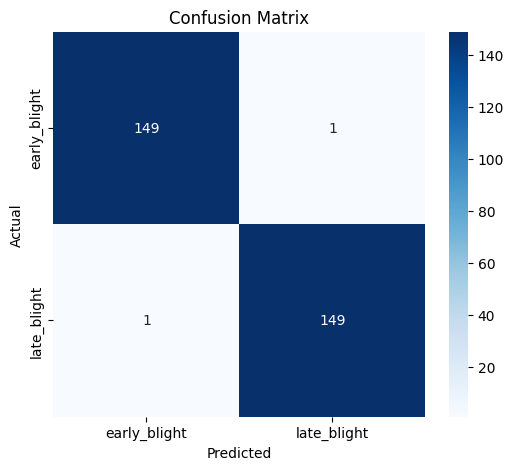

In [22]:
# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

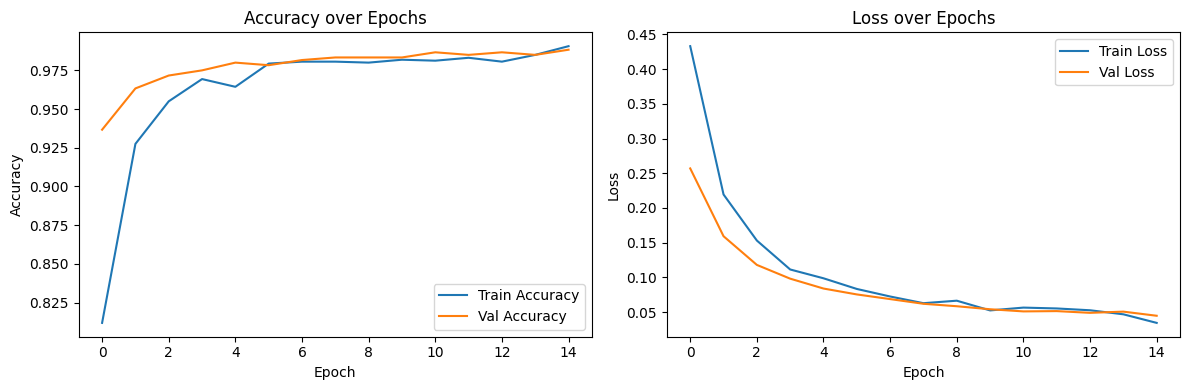

In [23]:
# ---- ACCURACY / LOSS CURVES (from training history) ----
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Epochs")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Epochs")

plt.tight_layout()
plt.savefig("accuracy_loss_curves.png")
plt.show()

In [25]:
#SAVE MODEL
model.save("blight_model.h5")
print("Model saved as blight_model.h5")

Model saved as blight_model.h5
